In [ ]:
import pandas as pd
import numpy as np


from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

In [4]:
df = pd.read_csv("navic_ml_ready.csv")

df.head()

,TOWC (s),Block Count,No of tracked channels,Acquisition status word1,Chan No-1,PRN-1,Channel Tracking Status-1,Doppler-1 (Hz),C/NO-1 (dB-Hz),PR-1 (m),...,NEW Code - Carrier-5 (m),Carrier Delay-6 (meters),Corrected Carrier Range-6 (m),Code - Carrier-6 (m),NEW Code - Carrier-6 (m),Carrier Delay-7 (meters),Corrected Carrier Range-7 (m),Code - Carrier-7 (m),NEW Code - Carrier-7 (m),Predicted_value
0,442800,1283534,7,1403562,1,1,2580,-1615.817017,42.984573,10554080.66,...,13.356979,38279163.48,38279168.00,-10.005910,7.591008,39038691.51,39038696.03,5.816288,28.574394,0
1,442801,1283535,7,1403562,1,1,2580,-1615.728149,42.950333,10554492.96,...,16.739483,38279166.10,38279167.32,-6.976118,10.620826,39038703.95,39038705.17,9.025921,31.784089,0
2,442802,1283536,7,1403562,1,1,2580,-1615.585327,41.682514,10554903.60,...,14.632475,38279168.70,38279171.95,-9.173725,8.423233,39038716.35,39038719.61,7.009730,29.767946,0
3,442803,1283537,7,1403562,1,1,2580,-1615.757813,42.820030,10555316.61,...,12.797277,38279171.05,38279176.11,-10.584458,7.012520,39038728.51,39038733.57,5.203156,27.961414,0
4,442804,1283538,7,1403562,1,1,2580,-1616.135864,42.741901,10555728.47,...,16.698533,38279173.36,38279174.79,-7.292976,10.304016,39038740.62,39038742.05,8.613542,31.371852,0


In [10]:
df['sat_distance_4'] = np.sqrt(
    df['Satellite X Position-4 (m)']**2 +
    df['Satellite Y Position-4 (m)']**2 +
    df['Satellite Z Position-4 (m)']**2
)

df['sat_speed_4'] = np.sqrt(
    df['Satellite X Velocity-4 (m/s)']**2 +
    df['Satellite Y Velocity-4 (m/s)']**2 +
    df['Satellite Z Velocity-4 (m/s)']**2
)

print(df[['sat_distance_4','sat_speed_4']].head())

   sat_distance_4  sat_speed_4
0    4.207237e+07  1532.910697
1    4.207236e+07  1532.923985
2    4.207236e+07  1532.937152
3    4.207236e+07  1532.950439
4    4.207236e+07  1532.963607


C:\Users\sakshi\AppData\Local\Temp\ipykernel_11160\3795699122.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sat_distance_4'] = np.sqrt(
C:\Users\sakshi\AppData\Local\Temp\ipykernel_11160\3795699122.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sat_speed_4'] = np.sqrt(


In [11]:
features = [

'TOWC (s)',

'Satellite X Position-4 (m)',
'Satellite Y Position-4 (m)',
'Satellite Z Position-4 (m)',

'Satellite X Velocity-4 (m/s)',
'Satellite Y Velocity-4 (m/s)',
'Satellite Z Velocity-4 (m/s)',

'sat_distance_4',
'sat_speed_4'

]

X_data = df[features]

X_data.head()

,TOWC (s),Satellite X Position-4 (m),Satellite Y Position-4 (m),Satellite Z Position-4 (m),Satellite X Velocity-4 (m/s),Satellite Y Velocity-4 (m/s),Satellite Z Velocity-4 (m/s),sat_distance_4,sat_speed_4
0,442800,-16161453.03,38759555.64,2566746.810,301.824219,223.144623,-1486.244873,4.207237e+07,1532.910697
1,442801,-16161151.19,38759778.76,2565260.559,301.857330,223.099243,-1486.258667,4.207236e+07,1532.923985
2,442802,-16160849.32,38760001.84,2563774.294,301.890411,223.053864,-1486.272339,4.207236e+07,1532.937152
3,442803,-16160547.41,38760224.87,2562288.015,301.923492,223.008484,-1486.286133,4.207236e+07,1532.950439
4,442804,-16160245.47,38760447.86,2560801.722,301.956573,222.963089,-1486.299805,4.207236e+07,1532.963607


In [7]:
df['X_future'] = df[
    'Satellite X Position-4 (m)'
].shift(-1)

df['Y_future'] = df[
    'Satellite Y Position-4 (m)'
].shift(-1)

df['Z_future'] = df[
    'Satellite Z Position-4 (m)'
].shift(-1)

df = df.dropna()

y_data = df[
[
'X_future',
'Y_future',
'Z_future'
]

]

y_data.head()

,X_future,Y_future,Z_future
0,-16161151.19,38759778.76,2565260.559
1,-16160849.32,38760001.84,2563774.294
2,-16160547.41,38760224.87,2562288.015
3,-16160245.47,38760447.86,2560801.722
4,-16159943.49,38760670.80,2559315.416


In [39]:
total=len(df)

train_end=int(
total*.70
)

val_end=int(
total*.80
)


X_train_raw=X_data[:train_end]

X_val_raw=X_data[
train_end:val_end
]

X_test_raw=X_data[
val_end:
]


y_train_raw=y_data[
:train_end
]

y_val_raw=y_data[
train_end:val_end
]

y_test_raw=y_data[
val_end:
]

In [ ]:
feature_scaler=MinMaxScaler()

target_scaler=MinMaxScaler()


X_train_scaled=feature_scaler.fit_transform(
X_train_raw
)

X_val_scaled=feature_scaler.transform(
X_val_raw
)

X_test_scaled=feature_scaler.transform(
X_test_raw
)


y_train_scaled=target_scaler.fit_transform(
y_train_raw
)

y_val_scaled=target_scaler.transform(
y_val_raw
)

y_test_scaled=target_scaler.transform(
y_test_raw
)


(86338, 60, 9)
(86338, 3)


In [40]:
SEQ_LEN=100


def create_sequences(X,y):

    X_seq=[]
    y_seq=[]

    for i in range(
    len(X)-SEQ_LEN
    ):

        X_seq.append(
        X[i:i+SEQ_LEN]
        )

        y_seq.append(
        y[i+SEQ_LEN]
        )

    return np.array(
    X_seq
    ),np.array(
    y_seq
    )


X_train,y_train=create_sequences(
X_train_scaled,
y_train_scaled
)

X_val,y_val=create_sequences(
X_val_scaled,
y_val_scaled
)

X_test,y_test=create_sequences(
X_test_scaled,
y_test_scaled
)


print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

NameError: name 'X_train_scaled' is not defined

In [41]:
model=Sequential()

model.add(

LSTM(
64,
return_sequences=True,
input_shape=(
X_train.shape[1],
X_train.shape[2]
)
)
)

model.add(
Dropout(.3)
)

model.add(

LSTM(
32
)
)

model.add(
Dropout(.3)
)

model.add(

Dense(
16,
activation='relu'
)
)

model.add(
Dense(3)
)

model.summary()

d:\Autonav_Project\tf_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,939 (124.76 KB)

 Trainable params: 31,939 (124.76 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(

optimizer='adam',

loss='mse',

metrics=['mae']
)

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [50]:
history=model.fit(

X_train,
y_train,

validation_data=(
X_val,
y_val
),

epochs=20,

batch_size=128,

callbacks=[
early_stop
]
)


Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 36s 75ms/step - loss: 0.0036 - mae: 0.0453 - val_loss: 0.0213 - val_mae: 0.0999
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - loss: 0.0022 - mae: 0.0355 - val_loss: 0.0289 - val_mae: 0.1141
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - loss: 0.0017 - mae: 0.0309 - val_loss: 0.0378 - val_mae: 0.1219
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - loss: 0.0014 - mae: 0.0282 - val_loss: 0.0293 - val_mae: 0.1156
Epoch 5/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - loss: 0.0012 - mae: 0.0264 - val_loss: 0.0448 - val_mae: 0.1264
Epoch 6/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 0.0011 - mae: 0.0249 - val_loss: 0.0930 - val_mae: 0.1719
Epoch 7/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - loss: 9.9545e-04 - mae: 0.0234 - val_loss: 0.0733 - val_mae: 0.1502
Epoch 8/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - loss: 8.9602e-04 - mae: 0.0221 - val_loss: 0.0561 - val_mae: 0.1258
Epoch 9/20
473/473 ━━━━━━━━━━━━━

In [51]:
test_loss,test_mae = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:",test_loss)
print("Test MAE:",test_mae)

540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0384 - mae: 0.1724
Test Loss: 0.03840359300374985
Test MAE: 0.17241770029067993


In [52]:
pred=model.predict(X_test)

pred_real=target_scaler.inverse_transform(
    pred
)

actual_real=target_scaler.inverse_transform(
    y_test
)

540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step


In [53]:
rmse_x=np.sqrt(

mean_squared_error(
actual_real[:,0],
pred_real[:,0]
)
)

rmse_y=np.sqrt(

mean_squared_error(
actual_real[:,1],
pred_real[:,1]
)
)

rmse_z=np.sqrt(

mean_squared_error(
actual_real[:,2],
pred_real[:,2]
)
)

print("RMSE X:",rmse_x)
print("RMSE Y:",rmse_y)
print("RMSE Z:",rmse_z)

RMSE X: 950532.2354509183
RMSE Y: 881004.7623753677
RMSE Z: 10029506.011161374


In [54]:
print(
r2_score(
actual_real[:,0],
pred_real[:,0]
)
)

print(
r2_score(
actual_real[:,1],
pred_real[:,1]
)
)

print(
r2_score(
actual_real[:,2],
pred_real[:,2]
)
)

-0.7237069926986
0.6659836692802988
-2.68357742654462


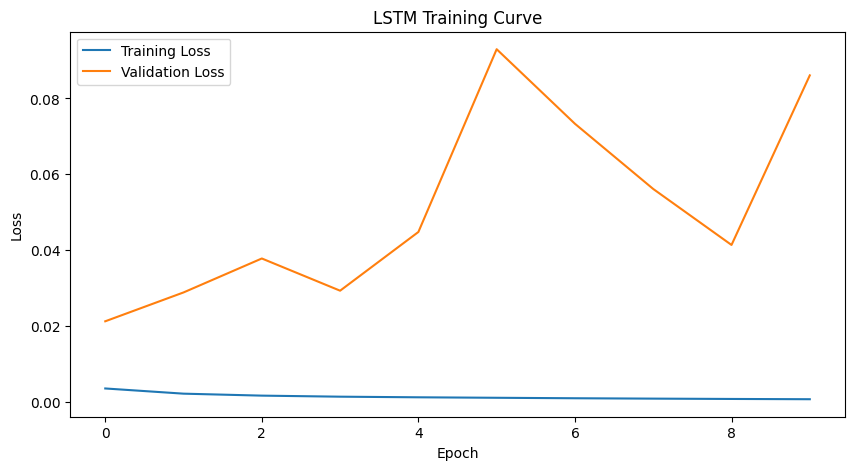

In [55]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(
history.history['loss'],
label='Training Loss'
)

plt.plot(
history.history['val_loss'],
label='Validation Loss'
)

plt.legend()

plt.title(
'LSTM Training Curve'
)

plt.xlabel(
'Epoch'
)

plt.ylabel(
'Loss'
)

plt.show()

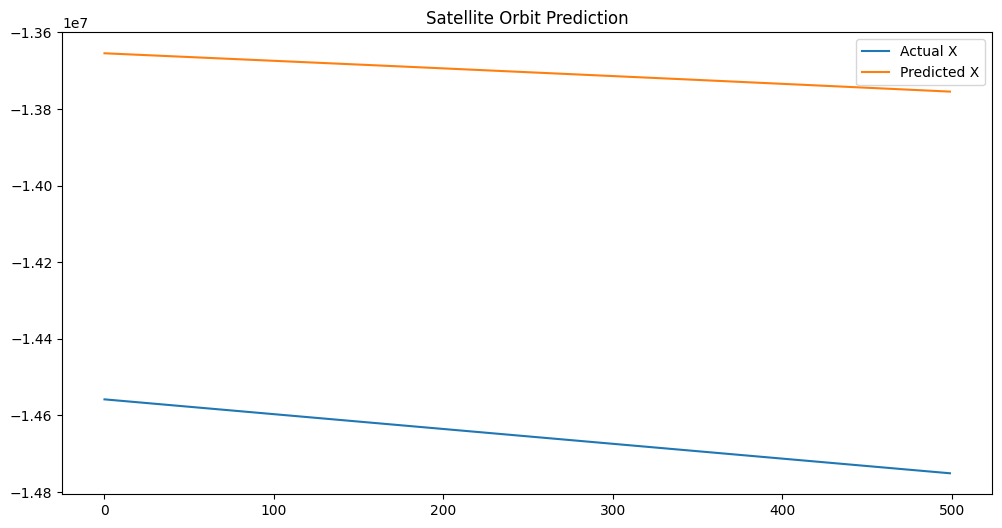

In [56]:
plt.figure(figsize=(12,6))

plt.plot(
actual_real[:500,0],
label='Actual X'
)

plt.plot(
pred_real[:500,0],
label='Predicted X'
)

plt.legend()

plt.title(
'Satellite Orbit Prediction'
)

plt.show()